description(v3)

__v2からの主な変更__

- 手動CV実装
- 前処理見直し (myload.py)
- StratifiedKFold-CV (by 5-quantiles of target variable)
- EDAは別ファイルへ分離

__リファクタリング__

変数名

- 初期読み込みデータ: train, submit
- 提出用データ: submit_pred
- feature engineering, train_test_split前までのデータ: X, y
- train_test_split後のデータ: X_train, X_test, y_train, y_test (サフィックスがフル表記)
- CVのカレントホールドの学習データ: x_tr, y_tr (小文字 ＆ サフィックスが省略表記)
- CVのカレントホールドの検証データ: x_va, y_va (小文字 ＆ サフィックスが省略表記)

In [1]:
# first import
import warnings
from importlib import reload

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from polars import selectors as cs

%matplotlib inline

warnings.filterwarnings('ignore')
from module import myload

reload(myload)
from module.myload import load_data

print("first import completed")

train, submit = load_data(20)
print("data load completed")
print(f"train: {train.shape}")
print(f"submit : {submit.shape}")
print(f"diff col : {set(train.columns) - set(submit.columns)}")

first import completed
data load completed
train: (1458, 81)
submit : (1459, 79)
diff col : {'SalePrice', 'price_bin'}


In [2]:
# feature engineering (temporaly, do nothing)

X = train.copy()
y = X.pop("SalePrice")
bins = X.pop("price_bin")
submit_index = submit.index

X = pl.DataFrame(X).select(cs.numeric()).to_pandas()
submit = pl.DataFrame(submit).select(cs.numeric()).to_pandas()

X.shape, submit.shape

((1458, 33), (1459, 33))

In [4]:
# base models definition
from module.base_models import provide_base_models

models = provide_base_models()
print(f"base models were built with target transformer : {models.keys()}")

base models were built with target transformer : dict_keys(['enet', 'lasso', 'xgb', 'lgbm'])


In [5]:
# valid preparation (train_test_split)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, bin_train, _ = train_test_split(X,y,bins,test_size=0.2,random_state=711,stratify=bins)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
y_train.name += "_train"
y_test.name += "_test"

# sns.histplot([y_train,y_test],multiple="dodge")

(1166, 33) (292, 33) (1166,) (292,)


In [6]:
# stratified 5-fold cross validation

from sklearn.base import clone
from sklearn.metrics import root_mean_squared_log_error
from sklearn.model_selection import StratifiedKFold

folds = 5
skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=711)

score = []
for name, model in models.items():
    
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, bin_train)):
        # split cv dataset
        x_tr,x_va = X_train.iloc[tr_idx],X_train.iloc[va_idx]
        y_tr,y_va = y_train.iloc[tr_idx],y_train.iloc[va_idx]
        
        # fit and predict
        fold_model = clone(model)
        fold_model.fit(x_tr,y_tr)
        tr_pred = fold_model.predict(x_tr)
        va_pred = fold_model.predict(x_va)
                
        # register score
        score.append({
            "fold": fold,
            "model":name,
            "tr": root_mean_squared_log_error(y_tr, tr_pred),
            "va": root_mean_squared_log_error(y_va, va_pred)
            })
        
print("cv finishied. result is registered.")


cv finishied. result is registered.


Text(0.5, 1.0, 'cv mean score')

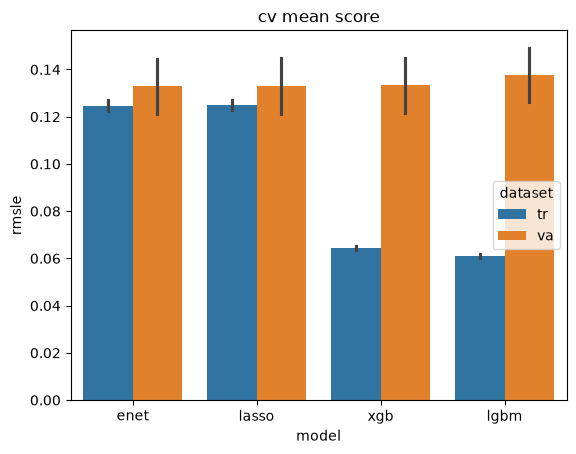

In [8]:
# show cv score

score_df = pd.DataFrame(score)
score_df["va-tr"] = score_df["va"] - score_df["tr"]
score_df.groupby("model")[["tr", "va", "va-tr"]].agg(["mean", "std"])

plot_df = score_df.melt(
        id_vars="model",
        value_vars=["tr", "va"],
        var_name="dataset",
        value_name="rmsle",
    )

ax = sns.barplot(data=plot_df,x="model",y="rmsle",hue="dataset",errorbar="sd")
ax.set_title("cv mean score")

In [12]:
# show test score

print("test scores\r\n")
for name, model in models.items():
    test_model = clone(model)
    test_model.fit(X_train,y_train)
    test_pred = test_model.predict(X_test)
    test_score = root_mean_squared_log_error(y_test, test_pred)
    print(f"{name}: {test_score:.5f}")

test scores

enet: 0.12894
lasso: 0.12915
xgb: 0.12127
lgbm: 0.12430


In [ ]:
# submit
final_models = models.copy()
for name in final_models:
    final_models[name].fit(X,y)

# final predict by mean of all models
predictions = np.column_stack([
    final_model.predict(submit) for final_model in final_models.values()])
submit_pred = np.mean(predictions, axis=1)

submit_df = pd.DataFrame({
    "Id": submit_index,
    "SalePrice": submit_pred
}).to_csv("../../data/submit.csv",index=False)